### Objective of Assignment 2

Choose a dataset of your preference and explore various data reduction techniques.

1. Data Reduction Techniques

1) Principal Component Analysis (PCA)
2) Factor Analysis
3) t-Distributed Stochastic Neighbor Embedding (t-SNE)
4) Linear Discriminant Analysis (LDA)


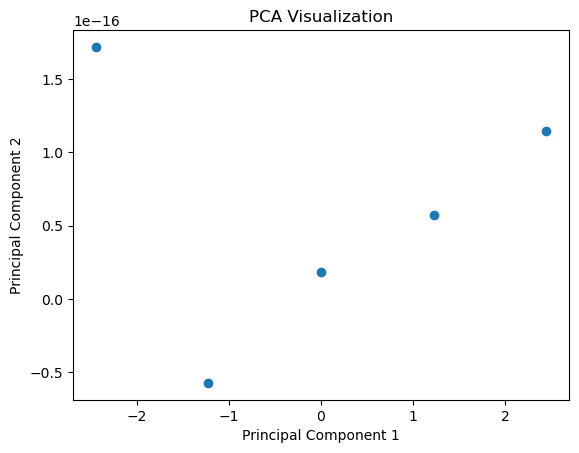

In [2]:
# 1) Principal Component Analysis (PCA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Sample data (replace with your actual data)
data = {'Feature1': [1, 2, 3, 4, 5],
        'Feature2': [2, 4, 6, 8, 10],
        'Feature3': [3, 6, 9, 12, 15]}

df = pd.DataFrame(data)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 principal components
principal_components = pca.fit_transform(scaled_data)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Visualize the data in the reduced dimension
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.show()

In [3]:
# 2. Factor Analysis
from factor_analyzer import FactorAnalyzer

# Sample data (replace with your own dataset)
data = {'var1': [1, 2, 3, 4, 5],
        'var2': [2, 4, 6, 8, 10],
        'var3': [3, 6, 9, 12, 15],
        'var4': [4, 8, 12, 16, 20],
        'var5': [5, 10, 15, 20, 25]}

df = pd.DataFrame(data)

# Check Bartlett's test of sphericity
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(df)
print(chi_square_value, p_value)

# Check Kaiser-Meyer-Olkin (KMO) test
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(df)
print(kmo_model)

# Create Factor Analysis object and perform factor analysis
fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(df)

# Get factor loadings
loadings = fa.loadings_
print(loadings)

# Get explained variance
ev, v = fa.get_eigenvalues()
print(ev)

# Visualize factor loadings
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(range(1, df.shape[1] + 1), ev)
plt.xticks(range(1, df.shape[1] + 1))
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

inf 0.0
0.5


/home/atg/.local/lib/python3.12/site-packages/factor_analyzer/factor_analyzer.py:109: RuntimeWarning: divide by zero encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)
/home/atg/.local/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


LinAlgError: Singular matrix

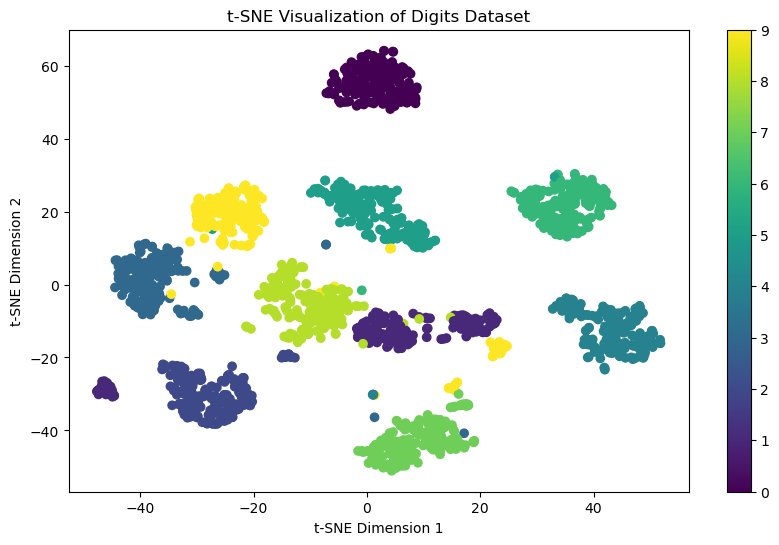

In [5]:
# 3. t-Distributed Stochastic Neighbor Embedding (t-SNE)
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Apply t-SNE to reduce dimensionality to 2D
tsne = TSNE(n_components=2, random_state=0)
X_2d = tsne.fit_transform(X)

# Visualize the reduced data
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.title('t-SNE Visualization of Digits Dataset')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [6]:
# 4. Linear Discriminant Analysis (LDA)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an LDA model
lda = LDA(n_components=2)

# Fit the model to the training data
lda.fit(X_train, y_train)

# Transform both training and testing data to the new space
X_train_transformed = lda.transform(X_train)
X_test_transformed = lda.transform(X_test)

# You can now use a classifier like Logistic Regression or SVM on the transformed data
from sklearn.linear_model import LogisticRegression

# Create a logistic regression model
clf = LogisticRegression()

# Fit the model to the transformed training data
clf.fit(X_train_transformed, y_train)

# Predict on the transformed testing data
y_pred = clf.predict(X_test_transformed)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0
